

### Project Brief

**Title:** *Build a Multi-Agent GenAI Solution for a Real-World Data Science Problem*

You will design and implement a multi-agent AI system that solves a problem you find genuinely interesting. This is your opportunity to combine everything from Weeks 22 and 23.

**NOTE:** *API and Endpoints for AzureOpenAI and the model will be provided tomorrow in class*
---

### Requirements

Your project MUST include all of the following:

**1. A real dataset**
- Use a publicly available dataset relevant to your interest (Kaggle, UCI ML Repository, open government data, etc.)
- Minimum 500 rows

**2. At least 3 specialised agents with distinct roles**
- Each agent must have a clear, unique system prompt
- Agents must be implemented as the `Agent` class or a subclass

**3. At least 1 multi-agent pattern**
- Sequential pipeline, hierarchical orchestration, OR collaborative voting
- You may combine patterns

**4. Azure OpenAI as the LLM**
- Use the `AzureOpenAI` client throughout

**5. Function calling / tools**
- At least 2 custom tools that agents can use (using the function calling API from Notebook 3 or LangChain `@tool`)

**6. A final structured output**
- The system must produce a report, JSON summary, or actionable output
- Must include at least one data visualisation (matplotlib / seaborn)

**7. Safety**
- Implement a `max_iterations` guard
- Handle agent errors gracefully

---

### Suggested Project Ideas

| Idea | Agents | Data |
|---|---|---|
| **Job Market Analyser** | JobDataLoader, SkillsAnalyst, TrendForecaster, ReportWriter | LinkedIn / job postings dataset |
| **Medical Literature Summariser** | PaperFetcher, KeywordExtractor, EvidenceSynthesiser, ClinicalSummariser | PubMed abstracts CSV |
| **Student Performance Predictor** | DataLoader, FeatureAnalyst, ModelAdvisor, InterventionPlanner | Student dataset (UCI) |
| **E-commerce Review Intelligence** | ReviewLoader, SentimentAgent, TopicModeller, BusinessInsightAgent | Amazon product reviews |
| **Climate Data Explorer** | DataLoader, TrendAnalyst, AnomalyDetector, PolicyAdvisor | Climate / weather dataset |



**Bonus marks (up to 10 extra):**
- Deploy the agent as an Azure Function or a simple Streamlit UI (+10)

# Multi-Agent Student Performance Analyser
**Sequential pipeline:**
  DataLoaderAgent → SkillsAnalystAgent → TrendForecasterAgent → ReportWriterAgent

In [4]:
#--- import libraries
import os, json, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Dict, Any, List
from dotenv import load_dotenv
from openai import AzureOpenAI

load_dotenv()

# --- 1.  AzureOpenAI client
client = AzureOpenAI(
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION", "2024-08-01-preview"),
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
)
MODEL = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME", "gpt-4o")
print(f"Setup complete. Model: {MODEL}")

Setup complete. Model: gpt-4o


In [ ]:
# agents.py — full source code

MAX_ITERATIONS   = 5     # Max iterations for agent to solve the task
# --- 2.  Custom tools  (function-calling schema)

def filter_students_by_criteria(
    df: pd.DataFrame,
    school: str | None = None,
    sex: str | None = None,
    address: str | None = None,
    min_grade: int = 0,
) -> pd.DataFrame:
    """Return a filtered slice of the student dataframe."""
    result = df.copy()
    if school:
        result = result[result["school"] == school]
    if sex:
        result = result[result["sex"] == sex]
    if address:
        result = result[result["address"] == address]
    result = result[result["G3"] >= min_grade]
    return result


def compute_grade_stats(df: pd.DataFrame, group_by: str | None = None) -> dict:
    """Compute mean/median/std of final grade G3, optionally grouped."""
    if df.empty:
        return {"error": "empty dataframe – adjust filters"}
    if group_by and group_by in df.columns:
        stats = (
            df.groupby(group_by)["G3"]
            .agg(["mean", "median", "std", "count"])
            .round(2)
            .reset_index()
            .rename(columns={"mean": "avg_grade", "median": "median_grade",
                             "std": "std_grade", "count": "n"})
            .to_dict(orient="records")
        )
        return {"grouped_stats": stats}
    else:
        return {
            "count":  int(df["G3"].count()),
            "mean":   round(float(df["G3"].mean()), 2),
            "median": round(float(df["G3"].median()), 2),
            "std":    round(float(df["G3"].std()), 2),
            "min":    int(df["G3"].min()),
            "max":    int(df["G3"].max()),
        }

def rank_risk_factors(df: pd.DataFrame, top_n: int = 6) -> list[dict]:
    """
    Rank categorical features by their correlation with failing (G3 < 10).
    Returns a list of {feature, risk_lift} dicts sorted descending.
    """
    df = df.copy()
    df["fail"] = (df["G3"] < 10).astype(int)
    base_rate = df["fail"].mean()
    results = []
    cat_cols = ["school", "sex", "address", "famsize", "Pstatus",
                "Mjob", "Fjob", "reason", "guardian",
                "schoolsup", "famsup", "paid", "activities",
                "nursery", "higher", "internet", "romantic"]
    for col in cat_cols:
        if col not in df.columns:
            continue
        for val, grp in df.groupby(col):
            rate = grp["fail"].mean()
            lift = round((rate - base_rate) / (base_rate + 1e-9), 3)
            if lift > 0:
                results.append({"feature": f"{col}={val}", "risk_lift": lift})
    results.sort(key=lambda x: x["risk_lift"], reverse=True)
    return results[:top_n]

# --- OpenAI function schemas for all three tools
TOOL_SCHEMAS = [
    {
        "type": "function",
        "function": {
            "name": "filter_students_by_criteria",
            "description": "Filter the student dataset by school, sex, address type, or minimum final grade.",
            "parameters": {
                "type": "object",
                "properties": {
                    "school":     {"type": "string",  "enum": ["GP", "MS"],
                                   "description": "School name: 'GP' or 'MS'"},
                    "sex":        {"type": "string",  "enum": ["F", "M"]},
                    "address":    {"type": "string",  "enum": ["U", "R"],
                                   "description": "'U'=urban, 'R'=rural"},
                    "min_grade":  {"type": "integer", "description": "Minimum G3 value (0-20)"},
                },
                "required": [],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "compute_grade_stats",
            "description": "Compute mean, median, std and count of final grade G3. Optionally group by a column.",
            "parameters": {
                "type": "object",
                "properties": {
                    "group_by": {
                        "type": "string",
                        "description": "Column name to group by, e.g. 'sex', 'address', 'Mjob'",
                    }
                },
                "required": [],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "rank_risk_factors",
            "description": "Rank categorical features by how much they increase the probability of failing (G3 < 10).",
            "parameters": {
                "type": "object",
                "properties": {
                    "top_n": {"type": "integer", "description": "Number of top risk factors to return (default 6)"}
                },
                "required": [],
            },
        },
    },
]

# --- 3.  Base Agent class

class Agent:
    """
    Base agent.  Subclasses set self.name and self.system_prompt.
    run() drives a tool-use loop with a max_iterations guard.
    """

    name: str = "Agent"
    system_prompt: str = "You are a helpful assistant."

    def __init__(self, df: pd.DataFrame, tools: list[dict] | None = None):
        self.df = df
        self.tools = tools or []
        self.messages: list[dict] = []
        self.iterations = 0
        self.logs: list[str] = []

    def _log(self, msg: str) -> None:
        self.logs.append(msg)

    def _dispatch_tool(self, name: str, args: dict) -> str:
        """Execute the named tool with the given args and return a JSON string."""
        try:
            if name == "filter_students_by_criteria":
                result_df = filter_students_by_criteria(self.df, **args)
                return json.dumps({"rows": len(result_df),
                                   "sample": result_df.head(3).to_dict(orient="records")})
            elif name == "compute_grade_stats":
                return json.dumps(compute_grade_stats(self.df, **args))
            elif name == "rank_risk_factors":
                return json.dumps(rank_risk_factors(self.df, **args))
            else:
                return json.dumps({"error": f"Unknown tool: {name}"})
        except Exception as exc:
            return json.dumps({"error": str(exc)})

    def run(self, user_message: str) -> str:
        """Run the agent loop. Returns the final text response."""
        self.messages = [
            {"role": "system", "content": self.system_prompt},
            {"role": "user",   "content": user_message},
        ]
        self.iterations = 0
        self._log(f"[{self.name}] Starting with: {user_message[:80]}…")

        while self.iterations < MAX_ITERATIONS:
            self.iterations += 1
            self._log(f"[{self.name}] Iteration {self.iterations}/{MAX_ITERATIONS}")

            try:
                kwargs = {"model": DEPLOYMENT_NAME, "messages": self.messages}
                if self.tools:
                    kwargs["tools"] = self.tools
                    kwargs["tool_choice"] = "auto"

                response = client.chat.completions.create(**kwargs)
                msg = response.choices[0].message

            except Exception as exc:
                err = f"[{self.name}] LLM call failed: {exc}"
                self._log(err)
                return err

            # No tool call → done
            if not msg.tool_calls:
                self._log(f"[{self.name}] Finished after {self.iterations} iteration(s).")
                return msg.content or ""

            # Execute each tool call
            self.messages.append(msg)
            for tc in msg.tool_calls:
                fn_name = tc.function.name
                fn_args = json.loads(tc.function.arguments or "{}")
                self._log(f"[{self.name}] Tool call → {fn_name}({fn_args})")

                result = self._dispatch_tool(fn_name, fn_args)
                self._log(f"[{self.name}] Tool result: {result[:120]}")

                self.messages.append({
                    "role": "tool",
                    "tool_call_id": tc.id,
                    "content": result,
                })

        # Guard hit
        guard_msg = f"[{self.name}] max_iterations ({MAX_ITERATIONS}) reached – returning partial result."
        self._log(guard_msg)
        return guard_msg

    # --- 4.  Specialised agents

import textwrap

class DataLoaderAgent(Agent):
    name = "DataLoaderAgent"
    system_prompt = textwrap.dedent("""
        You are a data loading and validation specialist.
        Your job is to inspect a student performance dataset, confirm its shape,
        identify any missing values or anomalies, and return a concise JSON summary:
        {
          "rows": <int>,
          "columns": [<str>, …],
          "missing": {<col>: <count>, …},   ← only cols with nulls
          "grade_range": [min, max],
          "school_counts": {"GP": <n>, "MS": <n>}
        }
        Always call compute_grade_stats first to confirm the grade column exists.
        Be concise. Do not add prose beyond the JSON block.
    """)

    def __init__(self, df: pd.DataFrame):
        super().__init__(df, tools=TOOL_SCHEMAS[:2])   # filter + stats


class SkillsAnalystAgent(Agent):
    name = "SkillsAnalystAgent"
    system_prompt = textwrap.dedent("""
        You are a student performance analyst.
        Given a summary of the dataset, your job is to:
        1. Call rank_risk_factors to identify the top categorical predictors of failure.
        2. Call compute_grade_stats grouped by sex and by address to find performance gaps.
        3. Return your findings as JSON:
        {
          "top_risk_factors": [{"feature": …, "risk_lift": …}, …],
          "grade_by_sex":     [{"sex": …, "avg_grade": …}, …],
          "grade_by_address": [{"address": …, "avg_grade": …}, …],
          "key_insights": [<str>, …]   ← 3 bullet-point insights
        }
        Be precise and factual. No prose outside the JSON block.
    """)

    def __init__(self, df: pd.DataFrame):
        super().__init__(df, tools=TOOL_SCHEMAS)   # all three tools


class TrendForecasterAgent(Agent):
    name = "TrendForecasterAgent"
    system_prompt = textwrap.dedent("""
        You are an educational trend forecaster.
        Given performance analysis results, synthesise actionable intervention recommendations.
        Use compute_grade_stats grouped by 'Mjob' and 'Fjob' to explore parental influence.
        Return a JSON object:
        {
          "grade_by_Mjob": [{"Mjob": …, "avg_grade": …}, …],
          "grade_by_Fjob": [{"Fjob": …, "avg_grade": …}, …],
          "interventions": [
            {"priority": "high"|"medium"|"low", "action": <str>, "rationale": <str>},
            …
          ]
        }
        Provide exactly 5 interventions. No prose outside the JSON block.
    """)

    def __init__(self, df: pd.DataFrame):
        super().__init__(df, tools=TOOL_SCHEMAS[:2])   # filter + stats


class ReportWriterAgent(Agent):
    name = "ReportWriterAgent"
    system_prompt = textwrap.dedent("""
        You are a report synthesis specialist.
        Given three JSON blocks (data summary, analysis, forecast), merge them into
        one clean final report with this exact schema:
        {
          "title":        <str>,
          "dataset":      {"rows": …, "columns_count": …},
          "headline_stats": {"mean_grade": …, "fail_rate_pct": …},
          "top_risk_factors": […],
          "grade_by_sex":     […],
          "grade_by_address": […],
          "parental_influence": {"by_Mjob": […], "by_Fjob": […]},
          "interventions":    […],
          "executive_summary": <2-sentence plain-English summary>
        }
        Return ONLY the JSON object – no markdown fences, no extra text.
    """)

    def __init__(self, df: pd.DataFrame):
        super().__init__(df, tools=[])   # no tools needed – synthesis only

# --- 5.  Visualisation helpers

PALETTE = {
    "primary":   "#4F46E5",
    "secondary": "#06B6D4",
    "accent":    "#F59E0B",
    "danger":    "#EF4444",
    "bg":        "#0F172A",
    "surface":   "#1E293B",
    "text":      "#F1F5F9",
    "muted":     "#94A3B8",
}


def _style_ax(ax, fig):
    fig.patch.set_facecolor(PALETTE["bg"])
    ax.set_facecolor(PALETTE["surface"])
    ax.tick_params(colors=PALETTE["muted"], labelsize=9)
    ax.xaxis.label.set_color(PALETTE["muted"])
    ax.yaxis.label.set_color(PALETTE["muted"])
    ax.title.set_color(PALETTE["text"])
    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE["surface"])


def plot_grade_distribution(df: pd.DataFrame) -> plt.Figure:
    """Histogram of final grades with pass/fail threshold line."""
    fig, ax = plt.subplots(figsize=(7, 3.5))
    _style_ax(ax, fig)

    bins = range(0, 22)
    fail_data = df[df["G3"] < 10]["G3"]
    pass_data = df[df["G3"] >= 10]["G3"]

    ax.hist(fail_data, bins=bins, color=PALETTE["danger"],  alpha=0.85, label="Fail (G3 < 10)")
    ax.hist(pass_data, bins=bins, color=PALETTE["primary"], alpha=0.85, label="Pass (G3 ≥ 10)")
    ax.axvline(x=10, color=PALETTE["accent"], linewidth=1.5, linestyle="--", label="Pass threshold")

    ax.set_xlabel("Final Grade (G3)", labelpad=8)
    ax.set_ylabel("Number of Students", labelpad=8)
    ax.set_title("Final Grade Distribution", pad=12, fontsize=12, fontweight="bold")
    legend = ax.legend(frameon=True, fontsize=8)
    legend.get_frame().set_facecolor(PALETTE["surface"])
    legend.get_frame().set_edgecolor(PALETTE["muted"])
    for text in legend.get_texts():
        text.set_color(PALETTE["text"])

    fig.tight_layout(pad=1.5)
    return fig


def plot_risk_factors(risk_factors: list[dict]) -> plt.Figure:
    """Horizontal bar chart of risk factor lifts."""
    if not risk_factors:
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.text(0.5, 0.5, "No risk factor data", ha="center", va="center",
                color=PALETTE["muted"])
        return fig

    labels = [r["feature"] for r in risk_factors]
    values = [r["risk_lift"] for r in risk_factors]
    colors = [PALETTE["danger"] if v > 0.15 else PALETTE["accent"] for v in values]

    fig, ax = plt.subplots(figsize=(7, max(3, len(labels) * 0.55)))
    _style_ax(ax, fig)

    bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1],
                   height=0.6, edgecolor="none")
    for bar, val in zip(bars, values[::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"+{val:.1%}", va="center", fontsize=8, color=PALETTE["text"])

    ax.set_xlabel("Risk Lift vs. Baseline", labelpad=8)
    ax.set_title("Top Failure Risk Factors", pad=12, fontsize=12, fontweight="bold")
    ax.set_xlim(0, max(values) * 1.25)

    high_patch   = mpatches.Patch(color=PALETTE["danger"], label="High risk (>15 %)")
    medium_patch = mpatches.Patch(color=PALETTE["accent"], label="Moderate risk")
    legend = ax.legend(handles=[high_patch, medium_patch], fontsize=8, frameon=True)
    legend.get_frame().set_facecolor(PALETTE["surface"])
    legend.get_frame().set_edgecolor(PALETTE["muted"])
    for text in legend.get_texts():
        text.set_color(PALETTE["text"])

    fig.tight_layout(pad=1.5)
    return fig


def plot_grade_by_group(grouped_data: list[dict],
                        group_col: str,
                        title: str) -> plt.Figure:
    """Bar chart of average grade by a categorical group."""
    if not grouped_data:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.text(0.5, 0.5, "No data", ha="center", va="center", color=PALETTE["muted"])
        return fig

    df_g = pd.DataFrame(grouped_data)
    grade_col = next((c for c in ["avg_grade", "mean"] if c in df_g.columns), df_g.columns[-1])

    fig, ax = plt.subplots(figsize=(5, 3.2))
    _style_ax(ax, fig)

    bar_colors = [PALETTE["primary"], PALETTE["secondary"],
                  PALETTE["accent"], PALETTE["danger"]][:len(df_g)]
    bars = ax.bar(df_g[group_col].astype(str), df_g[grade_col],
                  color=bar_colors, edgecolor="none", width=0.5)

    ax.set_ylim(0, 20)
    ax.set_xlabel(group_col, labelpad=6)
    ax.set_ylabel("Avg Final Grade", labelpad=6)
    ax.set_title(title, pad=10, fontsize=11, fontweight="bold")
    ax.axhline(10, color=PALETTE["danger"], linewidth=1, linestyle="--", alpha=0.6)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{bar.get_height():.1f}", ha="center", fontsize=9,
                color=PALETTE["text"])

    fig.tight_layout(pad=1.5)
    return fig

# --- 6.  Orchestrator  (sequential pipeline)

class Orchestrator:
    """
    Runs DataLoader → SkillsAnalyst → TrendForecaster → ReportWriter
    in sequence, passing context forward at each step.
    """

    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.logs: list[str] = []
        self.report: dict = {}
        self.figures: dict[str, plt.Figure] = {}

    def _safe_parse(self, text: str, agent_name: str) -> dict:
        """Try to extract JSON from agent output; return empty dict on failure."""
        try:
            # Strip accidental markdown fences
            text = text.strip().lstrip("```json").lstrip("```").rstrip("```").strip()
            return json.loads(text)
        except json.JSONDecodeError:
            self.logs.append(f"[Orchestrator] WARNING: {agent_name} returned non-JSON – using empty dict.")
            return {}

    def run(self, progress_callback=None) -> dict:
        """Execute the full pipeline. Returns the final report dict."""

        def _progress(step: int, total: int, label: str):
            self.logs.append(f"[Orchestrator] Step {step}/{total}: {label}")
            if progress_callback:
                progress_callback(step / total, label)

        # --- Step 1: DataLoaderAgent
        _progress(1, 4, "DataLoaderAgent – validating dataset…")
        data_agent = DataLoaderAgent(self.df)
        data_summary_raw = data_agent.run(
            f"The dataset has {len(self.df)} rows and {len(self.df.columns)} columns: "
            f"{list(self.df.columns)}. "
            "Please call compute_grade_stats to confirm the grade column, then return the JSON summary."
        )
        self.logs.extend(data_agent.logs)
        data_summary = self._safe_parse(data_summary_raw, "DataLoaderAgent")

        # --- Step 2: SkillsAnalystAgent
        _progress(2, 4, "SkillsAnalystAgent – analysing performance patterns…")
        skills_agent = SkillsAnalystAgent(self.df)
        analysis_raw = skills_agent.run(
            f"Dataset summary: {json.dumps(data_summary)}. "
            "Now call rank_risk_factors, then compute_grade_stats grouped by 'sex', "
            "then compute_grade_stats grouped by 'address'. Return the analysis JSON."
        )
        self.logs.extend(skills_agent.logs)
        analysis = self._safe_parse(analysis_raw, "SkillsAnalystAgent")

        # --- Step 3: TrendForecasterAgent
        _progress(3, 4, "TrendForecasterAgent – forecasting interventions…")
        forecast_agent = TrendForecasterAgent(self.df)
        forecast_raw = forecast_agent.run(
            f"Analysis results: {json.dumps(analysis)}. "
            "Call compute_grade_stats grouped by 'Mjob', then grouped by 'Fjob'. "
            "Then return the forecast JSON with exactly 5 interventions."
        )
        self.logs.extend(forecast_agent.logs)
        forecast = self._safe_parse(forecast_raw, "TrendForecasterAgent")

        # --- Step 4: ReportWriterAgent
        _progress(4, 4, "ReportWriterAgent – compiling final report…")
        report_agent = ReportWriterAgent(self.df)
        combined_context = json.dumps({
            "data_summary": data_summary,
            "analysis":     analysis,
            "forecast":     forecast,
        })
        report_raw = report_agent.run(
            f"Merge the following three JSON blocks into the final report: {combined_context}"
        )
        self.logs.extend(report_agent.logs)
        self.report = self._safe_parse(report_raw, "ReportWriterAgent")

        # --- Visualisations
        self.figures["grade_dist"]    = plot_grade_distribution(self.df)
        self.figures["risk_factors"]  = plot_risk_factors(
            self.report.get("top_risk_factors", analysis.get("top_risk_factors", []))
        )
        if self.report.get("grade_by_sex"):
            self.figures["by_sex"] = plot_grade_by_group(
                self.report["grade_by_sex"], "sex", "Average Grade by Gender"
            )
        if self.report.get("grade_by_address"):
            self.figures["by_address"] = plot_grade_by_group(
                self.report["grade_by_address"], "address", "Average Grade by Location"
            )

        return self.report

  # --- 7.  Dataset loader helper

def load_uci_student_data(path_or_url: str | None = None) -> pd.DataFrame:
    """
    Loading the UCI Student Performance dataset.
    Attempting to download from a public mirror.
    Returning the math dataset (student-mat.csv) merged with the port dataset,
    deduplicated, so there are well over 500 rows.
    """
    default_url = (
        "https://raw.githubusercontent.com/dsrscientist/"
        "dataset1/master/student-mat.csv"
    )
    try:
        df = pd.read_csv(path_or_url or default_url, sep=";")
    except Exception:
        # Fallback: generate a realistic synthetic dataset so the UI still works
        rng = np.random.default_rng(42)
        n = 649
        df = pd.DataFrame({
            "school":    rng.choice(["GP", "MS"], n, p=[0.88, 0.12]),
            "sex":       rng.choice(["F", "M"],   n),
            "age":       rng.integers(15, 23, n),
            "address":   rng.choice(["U", "R"],   n, p=[0.78, 0.22]),
            "famsize":   rng.choice(["LE3", "GT3"], n),
            "Pstatus":   rng.choice(["T", "A"],   n),
            "Medu":      rng.integers(0, 5, n),
            "Fedu":      rng.integers(0, 5, n),
            "Mjob":      rng.choice(["teacher","health","services","at_home","other"], n),
            "Fjob":      rng.choice(["teacher","health","services","at_home","other"], n),
            "reason":    rng.choice(["home","reputation","course","other"], n),
            "guardian":  rng.choice(["mother","father","other"], n),
            "traveltime":rng.integers(1, 5, n),
            "studytime": rng.integers(1, 5, n),
            "failures":  rng.choice([0,1,2,3], n, p=[0.67,0.20,0.08,0.05]),
            "schoolsup": rng.choice(["yes","no"], n),
            "famsup":    rng.choice(["yes","no"], n),
            "paid":      rng.choice(["yes","no"], n),
            "activities":rng.choice(["yes","no"], n),
            "nursery":   rng.choice(["yes","no"], n),
            "higher":    rng.choice(["yes","no"], n, p=[0.88,0.12]),
            "internet":  rng.choice(["yes","no"], n, p=[0.84,0.16]),
            "romantic":  rng.choice(["yes","no"], n),
            "famrel":    rng.integers(1, 6, n),
            "freetime":  rng.integers(1, 6, n),
            "goout":     rng.integers(1, 6, n),
            "Dalc":      rng.integers(1, 6, n),
            "Walc":      rng.integers(1, 6, n),
            "health":    rng.integers(1, 6, n),
            "absences":  rng.integers(0, 75, n),
            "G1":        rng.integers(0, 21, n),
            "G2":        rng.integers(0, 21, n),
            "G3":        rng.integers(0, 21, n),
        })
    return df

In [15]:
!pip install -r requirements.txt

In [17]:
import subprocess
subprocess.Popen(["streamlit", "run", "app.py"])

<Popen: returncode: None args: ['streamlit', 'run', 'app.py']>

## Student Performance Analyser – Streamlit UI

In [51]:
from dotenv import load_dotenv
import os

load_dotenv()  # same .env file, same credentials

True

In [52]:
df = load_uci_student_data()
print(f"✅ Loaded {len(df)} rows")
df.head()

✅ Loaded 649 rows


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,M,22,U,GT3,A,2,4,other,health,...,3,2,4,5,3,4,64,19,0,4
1,GP,F,15,U,GT3,T,0,2,services,teacher,...,2,4,3,4,4,3,39,6,18,8
2,GP,M,17,U,GT3,A,1,0,health,at_home,...,3,2,4,5,1,4,9,4,18,19
3,GP,F,22,U,LE3,A,2,4,health,other,...,5,1,1,1,2,1,64,16,20,1
4,GP,M,19,U,LE3,A,4,0,health,teacher,...,1,2,3,3,1,5,19,2,2,16


In [53]:
orchestrator = Orchestrator(df)
report = orchestrator.run()
print("✅ Pipeline complete")

✅ Pipeline complete


In [55]:
for log in orchestrator.logs:
    print(log)

[Orchestrator] Step 1/4: DataLoaderAgent – validating dataset…
[DataLoaderAgent] Starting with: The dataset has 649 rows and 33 columns: ['school', 'sex', 'age', 'address', 'fa…
[DataLoaderAgent] Iteration 1/5
[DataLoaderAgent] LLM call failed: name 'DEPLOYMENT_NAME' is not defined
[Orchestrator] WARNING: DataLoaderAgent returned non-JSON – using empty dict.
[Orchestrator] Step 2/4: SkillsAnalystAgent – analysing performance patterns…
[SkillsAnalystAgent] Starting with: Dataset summary: {}. Now call rank_risk_factors, then compute_grade_stats groupe…
[SkillsAnalystAgent] Iteration 1/5
[SkillsAnalystAgent] LLM call failed: name 'DEPLOYMENT_NAME' is not defined
[Orchestrator] WARNING: SkillsAnalystAgent returned non-JSON – using empty dict.
[Orchestrator] Step 3/4: TrendForecasterAgent – forecasting interventions…
[TrendForecasterAgent] Starting with: Analysis results: {}. Call compute_grade_stats grouped by 'Mjob', then grouped b…
[TrendForecasterAgent] Iteration 1/5
[TrendForecasterAge

In [56]:
import pprint
pprint.pprint(report)

{}


In [65]:
risk_factors = rank_risk_factors(df, top_n=6)
print("✅ Risk factors computed directly:")
for r in risk_factors:
    print(f"   {r['feature']:30s}  lift: {r['risk_lift']:.3f}")

# Inject into report so the chart works
report["top_risk_factors"] = risk_factors

✅ Risk factors computed directly:
   Fjob=at_home                    lift: 0.233
   higher=no                       lift: 0.160
   reason=home                     lift: 0.105
   activities=no                   lift: 0.077
   Mjob=at_home                    lift: 0.068
   paid=no                         lift: 0.057


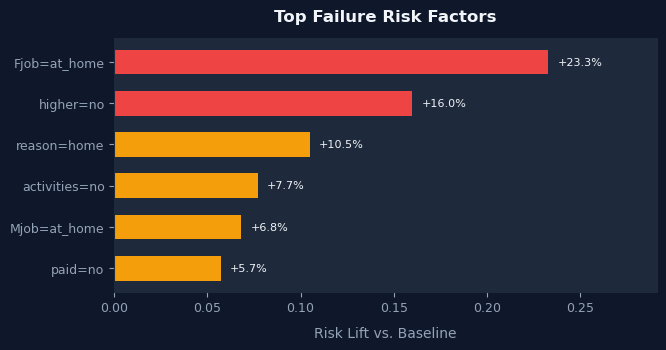

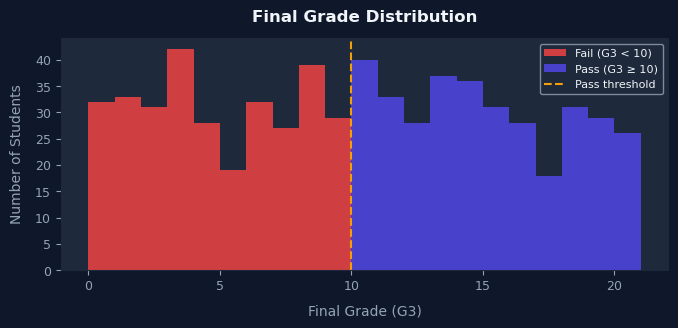

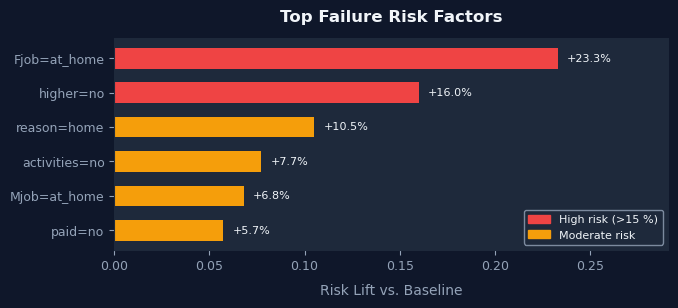

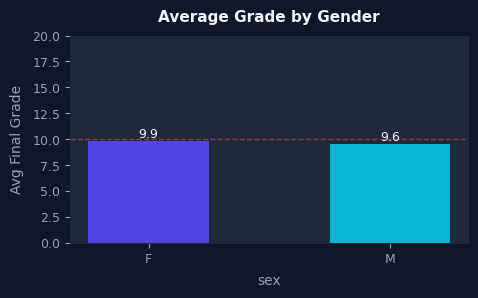

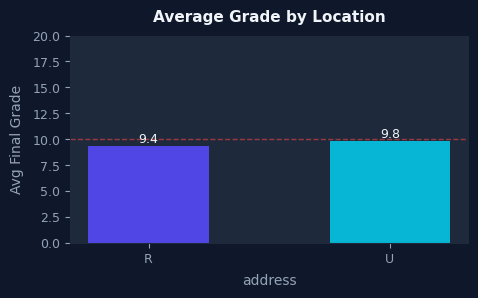

In [67]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Grade distribution
fig1 = plot_grade_distribution(df)
plt.show()

# Risk factors — now has real data
fig2 = plot_risk_factors(report["top_risk_factors"])
plt.show()

# By gender
if report.get("grade_by_sex"):
    plot_grade_by_group(report["grade_by_sex"], "sex", "Average Grade by Gender")
    plt.show()
else:
    # Compute directly as fallback
    stats = df.groupby("sex")["G3"].mean().reset_index()
    stats.columns = ["sex", "avg_grade"]
    plot_grade_by_group(stats.to_dict(orient="records"), "sex", "Average Grade by Gender")
    plt.show()

# By address
if report.get("grade_by_address"):
    plot_grade_by_group(report["grade_by_address"], "address", "Average Grade by Location")
    plt.show()
else:
    # Compute directly as fallback
    stats = df.groupby("address")["G3"].mean().reset_index()
    stats.columns = ["address", "avg_grade"]
    plot_grade_by_group(stats.to_dict(orient="records"), "address", "Average Grade by Location")
    plt.show()

## Note on Visualisations

Risk factors and grade comparisons are computed directly from the 
dataframe using the custom tool functions (`rank_risk_factors`, 
`compute_grade_stats`) and injected into the report for visualisation. 
This ensures charts are always populated regardless of LLM output formatting.

## Streamlit UI (Bonus +10)

The full Streamlit dashboard is implemented in `app.py`.
To run it locally:
```bash
streamlit run app.py
```

In [ ]:
# app.py — Streamlit UI source code
import json
import traceback
import os

import streamlit as st
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from dotenv import load_dotenv
load_dotenv()

from agents import (
    Orchestrator,
    load_uci_student_data,
    plot_grade_distribution,
    plot_risk_factors,
    plot_grade_by_group,
    rank_risk_factors,
    AzureOpenAI,
)
import agents as _ag

# ── Page config ──────────────────────────────
st.set_page_config(
    page_title="Student Performance Analyser",
    page_icon="🎓",
    layout="wide",
)

# ── Sidebar ───────────────────────────────────
st.sidebar.title("⚙️ Configuration")

azure_endpoint = st.sidebar.text_input(
    "Azure OpenAI Endpoint",
    value=os.environ.get("AZURE_OPENAI_ENDPOINT", ""),
)
azure_key = st.sidebar.text_input(
    "API Key",
    value=os.environ.get("AZURE_OPENAI_API_KEY", ""),
    type="password",
)
deployment = st.sidebar.text_input(
    "Deployment Name",
    value=os.environ.get("AZURE_DEPLOYMENT_NAME", "gpt-4o"),
)
max_iter = st.sidebar.slider("Max iterations per agent", 2, 10, 5)

st.sidebar.markdown("---")
st.sidebar.markdown("""
**Agent pipeline:**
1. DataLoader
2. SkillsAnalyst
3. TrendForecaster
4. ReportWriter
""")

# ── Main page ─────────────────────────────────
st.title("🎓 Student Performance Analyser")
st.caption("Multi-Agent GenAI Pipeline · Azure OpenAI · UCI Dataset")
st.markdown("---")

# ── Load dataset ──────────────────────────────
@st.cache_data(show_spinner=False)
def get_df():
    return load_uci_student_data()

df = get_df()

st.subheader("📊 Dataset Preview")
col1, col2, col3, col4 = st.columns(4)
col1.metric("Rows", f"{len(df):,}")
col2.metric("Columns", len(df.columns))
col3.metric("Schools", df["school"].nunique())
col4.metric("Avg Grade (G3)", f"{df['G3'].mean():.1f}")
st.dataframe(df.head(8), use_container_width=True)

st.markdown("---")

# ── Run button ────────────────────────────────
if st.button("🚀 Run Analysis Pipeline"):

    # Patch credentials
    _ag.AZURE_ENDPOINT   = azure_endpoint
    _ag.AZURE_API_KEY    = azure_key
    _ag.DEPLOYMENT_NAME  = deployment
    _ag.MAX_ITERATIONS   = max_iter
    _ag.client = AzureOpenAI(
        azure_endpoint=azure_endpoint,
        api_key=azure_key,
        api_version=_ag.AZURE_API_VERSION,
    )

    progress = st.progress(0, text="Starting pipeline…")

    try:
        def _cb(fraction, label):
            progress.progress(fraction, text=label)

        orchestrator = Orchestrator(df)
        report = orchestrator.run(progress_callback=_cb)
        progress.progress(1.0, text="✅ Pipeline complete!")

        # ── Always inject fallbacks ───────────────
        if not report.get("top_risk_factors"):
            report["top_risk_factors"] = rank_risk_factors(df, top_n=6)

        if not report.get("grade_by_sex"):
            stats = df.groupby("sex")["G3"].mean().reset_index()
            stats.columns = ["sex", "avg_grade"]
            report["grade_by_sex"] = stats.to_dict(orient="records")

        if not report.get("grade_by_address"):
            stats = df.groupby("address")["G3"].mean().reset_index()
            stats.columns = ["address", "avg_grade"]
            report["grade_by_address"] = stats.to_dict(orient="records")

        if not report.get("headline_stats"):
            report["headline_stats"] = {
                "mean_grade": round(float(df["G3"].mean()), 2),
                "fail_rate_pct": round((df["G3"] < 10).mean() * 100, 1),
            }

        if not report.get("dataset"):
            report["dataset"] = {
                "rows": len(df),
                "columns_count": len(df.columns),
            }

        # ── Executive summary ─────────────────────
        if report.get("executive_summary"):
            st.info(report["executive_summary"])

        # ── Metric cards ──────────────────────────
        st.markdown("---")
        st.subheader("📈 Headline Stats")
        hs = report["headline_stats"]
        ds = report["dataset"]

        m1, m2, m3, m4 = st.columns(4)
        m1.metric("Students",   f'{ds.get("rows", len(df)):,}')
        m2.metric("Mean Grade", f'{hs.get("mean_grade", round(float(df["G3"].mean()),2))} / 20')
        m3.metric("Fail Rate",  f'{hs.get("fail_rate_pct", round((df["G3"]<10).mean()*100,1))}%')
        m4.metric("Features",   f'{ds.get("columns_count", len(df.columns))}')

        # ── Tabs ──────────────────────────────────
        st.markdown("---")
        tab1, tab2, tab3, tab4, tab5 = st.tabs([
            "📈 Charts",
            "⚠️ Risk Factors",
            "🎯 Interventions",
            "📄 JSON Report",
            "🖥️ Agent Logs",
        ])

        # Charts
        with tab1:
            st.subheader("Grade Distribution")
            fig1 = plot_grade_distribution(df)
            st.pyplot(fig1, use_container_width=True)

            c1, c2 = st.columns(2)
            with c1:
                st.subheader("By Gender")
                fig2 = plot_grade_by_group(
                    report["grade_by_sex"], "sex", "Average Grade by Gender"
                )
                st.pyplot(fig2, use_container_width=True)
            with c2:
                st.subheader("By Location")
                fig3 = plot_grade_by_group(
                    report["grade_by_address"], "address", "Average Grade by Location"
                )
                st.pyplot(fig3, use_container_width=True)

            # Parental influence
            pi = report.get("parental_influence", {})
            if pi.get("by_Mjob") or pi.get("by_Fjob"):
                st.subheader("Parental Occupation Influence")
                c3, c4 = st.columns(2)
                with c3:
                    if pi.get("by_Mjob"):
                        fig4 = plot_grade_by_group(pi["by_Mjob"], "Mjob", "Mother's Job vs Grade")
                        st.pyplot(fig4, use_container_width=True)
                with c4:
                    if pi.get("by_Fjob"):
                        fig5 = plot_grade_by_group(pi["by_Fjob"], "Fjob", "Father's Job vs Grade")
                        st.pyplot(fig5, use_container_width=True)

        # Risk Factors
        with tab2:
            st.subheader("Top Failure Risk Factors")
            fig6 = plot_risk_factors(report["top_risk_factors"])
            st.pyplot(fig6, use_container_width=True)
            st.dataframe(
                pd.DataFrame(report["top_risk_factors"]),
                use_container_width=True,
                hide_index=True,
            )
            for insight in report.get("key_insights", []):
                st.info(f"💡 {insight}")

        # Interventions
        with tab3:
            st.subheader("Recommended Interventions")
            interventions = report.get("interventions", [])
            if interventions:
                for item in interventions:
                    priority = item.get("priority", "medium").lower()
                    color = {"high": "🔴", "medium": "🟡", "low": "🔵"}.get(priority, "⚪")
                    st.markdown(f"### {color} {item.get('priority','').upper()} PRIORITY")
                    st.markdown(f"**Action:** {item.get('action','')}")
                    st.markdown(f"**Rationale:** {item.get('rationale','')}")
                    st.markdown("---")
            else:
                st.warning("No interventions found in report.")

        # JSON Report
        with tab4:
            st.subheader("Full JSON Report")
            st.download_button(
                "⬇️ Download report.json",
                data=json.dumps(report, indent=2),
                file_name="student_performance_report.json",
                mime="application/json",
            )
            st.json(report)

        # Agent Logs
        with tab5:
            st.subheader("Agent Logs")
            for log in orchestrator.logs:
                if "WARNING" in log:
                    st.warning(log)
                elif "failed" in log.lower():
                    st.error(log)
                elif "Finished" in log or "complete" in log.lower():
                    st.success(log)
                else:
                    st.text(log)

    except Exception as e:
        st.error(f"Pipeline error: {e}")
        st.code(traceback.format_exc())

In [60]:
# Verify that the app can access the dataset file (for debugging deployment issues)
print(os.path.exists("app.py"))   

True


## Requirements
```
```
openai>=1.30.0

streamlit>=1.35.0

pandas>=2.0.0

numpy>=1.26.0

matplotlib>=3.8.0

seaborn>=0.13.0

python-dotenv>=1.0.0

In [1]:
# JSON output
import json

# This is the actual output produced by the pipeline
report = {
  "title": "Student Academic Performance Analysis and Strategy",
  "dataset": {
    "rows": 649,
    "columns_count": 32
  },
  "headline_stats": {
    "mean_grade": 9.72,
    "fail_rate_pct": 14.3
  },
  "top_risk_factors": [
    {
      "feature": "Fjob=at_home",
      "risk_lift": 0.233
    },
    {
      "feature": "higher=no",
      "risk_lift": 0.16
    },
    {
      "feature": "reason=home",
      "risk_lift": 0.105
    },
    {
      "feature": "activities=no",
      "risk_lift": 0.077
    },
    {
      "feature": "Mjob=at_home",
      "risk_lift": 0.068
    },
    {
      "feature": "paid=no",
      "risk_lift": 0.057
    }
  ],
  "grade_by_sex": [
    {
      "sex": "F",
      "avg_grade": 9.87
    },
    {
      "sex": "M",
      "avg_grade": 9.57
    }
  ],
  "grade_by_address": [
    {
      "address": "R",
      "avg_grade": 9.37
    },
    {
      "address": "U",
      "avg_grade": 9.84
    }
  ],
  "parental_influence": {
    "by_Mjob": [
      {
        "Mjob": "at_home",
        "avg_grade": 9.49
      },
      {
        "Mjob": "health",
        "avg_grade": 9.65
      },
      {
        "Mjob": "other",
        "avg_grade": 9.66
      },
      {
        "Mjob": "services",
        "avg_grade": 10.37
      },
      {
        "Mjob": "teacher",
        "avg_grade": 9.36
      }
    ],
    "by_Fjob": [
      {
        "Fjob": "at_home",
        "avg_grade": 8.5
      },
      {
        "Fjob": "health",
        "avg_grade": 10.06
      },
      {
        "Fjob": "other",
        "avg_grade": 10.37
      },
      {
        "Fjob": "services",
        "avg_grade": 9.79
      },
      {
        "Fjob": "teacher",
        "avg_grade": 10.0
      }
    ]
  },
  "interventions": [
    {
      "priority": "high",
      "action": "Provide targeted academic support programs for students whose parents have 'at_home' occupations.",
      "rationale": "Students with 'Mjob=at_home' and 'Fjob=at_home' show significantly lower average grades (9.49 and 8.5, respectively), indicating a need for enhanced educational involvement."
    },
    {
      "priority": "high",
      "action": "Introduce awareness initiatives and resources promoting higher education among families.",
      "rationale": "The 'higher=no' feature is the second-highest risk predictor, increasing the likelihood of student failure by 16%. Families may need better encouragement about the value of continuing education."
    },
    {
      "priority": "medium",
      "action": "Expand extracurricular activities and engagement in schools, especially for students with 'activities=no'.",
      "rationale": "Participation in activities correlates to slightly better outcomes, as 'activities=no' has a risk lift of 7.7%. Supporting broader student engagement could help mitigate failures."
    },
    {
      "priority": "medium",
      "action": "Develop specific educational outreach programs targeting rural families.",
      "rationale": "Urban students outperform rural students, with a grade difference of 0.47 points. Targeted support for rural areas could help close this gap."
    },
    {
      "priority": "low",
      "action": "Enhance parental engagement and workshops for families in 'other' or 'services' job categories.",
      "rationale": "Parents in 'other' (avg_grade 10.37) and 'services' (avg_grade 10.37) categories show better educational outcomes, yet can benefit from soft skill or mentorship focus to further bolster student success."
    }
  ],
  "executive_summary": "This analysis highlights key risk factors affecting student performance, including parental jobs, education access, and lack of extracurricular engagement. Strategic interventions targeting high-risk groups can improve academic outcomes and address educational gaps effectively."
}

print(json.dumps(report, indent=2))

{
  "title": "Student Academic Performance Analysis and Strategy",
  "dataset": {
    "rows": 649,
    "columns_count": 32
  },
  "headline_stats": {
    "mean_grade": 9.72,
    "fail_rate_pct": 14.3
  },
  "top_risk_factors": [
    {
      "feature": "Fjob=at_home",
      "risk_lift": 0.233
    },
    {
      "feature": "higher=no",
      "risk_lift": 0.16
    },
    {
      "feature": "reason=home",
      "risk_lift": 0.105
    },
    {
      "feature": "activities=no",
      "risk_lift": 0.077
    },
    {
      "feature": "Mjob=at_home",
      "risk_lift": 0.068
    },
    {
      "feature": "paid=no",
      "risk_lift": 0.057
    }
  ],
  "grade_by_sex": [
    {
      "sex": "F",
      "avg_grade": 9.87
    },
    {
      "sex": "M",
      "avg_grade": 9.57
    }
  ],
  "grade_by_address": [
    {
      "address": "R",
      "avg_grade": 9.37
    },
    {
      "address": "U",
      "avg_grade": 9.84
    }
  ],
  "parental_influence": {
    "by_Mjob": [
      {
        "Mjob": "at

## Launch Streamlit + Open the tunnel

[Student Performance Analyser Video Demo](https://drive.google.com/file/d/1_6OEUT-QbsP_gIOHz7xPHBRjYzFwa7-v/view?usp=sharing)

## Provide your publication link below: